In [1]:
from pathlib import Path
import warnings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import pygmt
from pygmt_helper import plotting

import nn_gmm as nng

In [2]:
imdb_ffp = Path("/Users/claudy/dev/work/data/nn_gmm/202505_CS200m_imdb.db")

In [3]:
with nng.IMDB(imdb_ffp, readonly=True) as imdb:
    site_real_df = imdb.get_site_df(max_grid_level=-1, min_grid_level=-1)
    site_0_df = imdb.get_site_df(max_grid_level=0, min_grid_level=0)
    site_1_df = imdb.get_site_df(max_grid_level=1, min_grid_level=1)
    site_2_df = imdb.get_site_df(max_grid_level=2, min_grid_level=2)
    site_3_df = imdb.get_site_df(max_grid_level=3, min_grid_level=3)
    site_4_df = imdb.get_site_df(max_grid_level=4, min_grid_level=4)

In [4]:
map_data = plotting.NZMapData.load(high_res_topo=False)
# map_data = None

In [ ]:
def plot_sites(site_df: pd.DataFrame, region: str = None, region_key: str = None, map_data: plotting.NZMapData = None):
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", UserWarning)
        fig = plotting.gen_region_fig(
            region=region,
            map_data=map_data,
            plot_kwargs={
                    "highway_pen_width": 0.1,
                    "coastline_pen_width": 0.01,
                    "topo_cmap": "gray",  # etopo1 geo
                    "topo_cmap_min": 0,
                    "topo_cmap_max": 3700,
                    "topo_cmap_inc": 250,
                    "topo_cmap_reverse": True,
            },
            config_options=dict(
                MAP_FRAME_TYPE="plain",
                FORMAT_GEO_MAP="ddd.xx",
                MAP_GRID_PEN="0.5p,gray",
                MAP_TICK_PEN_PRIMARY="1p,black",
                MAP_FRAME_PEN="1p,black",
                MAP_FRAME_AXES="WSne",
            ),
            plot_roads=False,
        )

    fig.plot(x=site_df["lon"],
            y=site_df["lat"],
            style="c0.1c",
            pen="black",
            fill="red",
            label="Real Sites")

    fig.show()

In [6]:
def plot_vs30_z1p0_distribution(site_df: pd.DataFrame):
    vs30_bins = np.linspace(0, 1500, 25)
    z1p0_bins = np.linspace(0, 1.6, 25)

    fig, (ax1, ax2) = plt.subplots(1, 2,figsize=(16, 5))

    ax1.hist(site_df.vs30, bins=vs30_bins, color="blue", edgecolor="black", alpha=0.7)

    ax1.grid(linewidth=0.5, alpha=0.5, linestyle="--")
    ax1.set_xlabel("Vs30 (m/s)")
    ax1.set_ylabel("Count")
    ax1.set_xlim(0, 1500)

    ax2.hist(site_df.z1p0, bins=z1p0_bins, color="green", edgecolor="black", alpha=0.7)

    ax2.grid(linewidth=0.5, alpha=0.5, linestyle="--")
    ax2.set_xlabel("Z1.0 (m)")
    ax2.set_ylabel("Count")
    ax2.set_xlim(0, 1.6)

    fig.tight_layout()

## Real Sites

In [7]:
print(f"Number of sites: {len(site_real_df)}")

Number of sites: 414


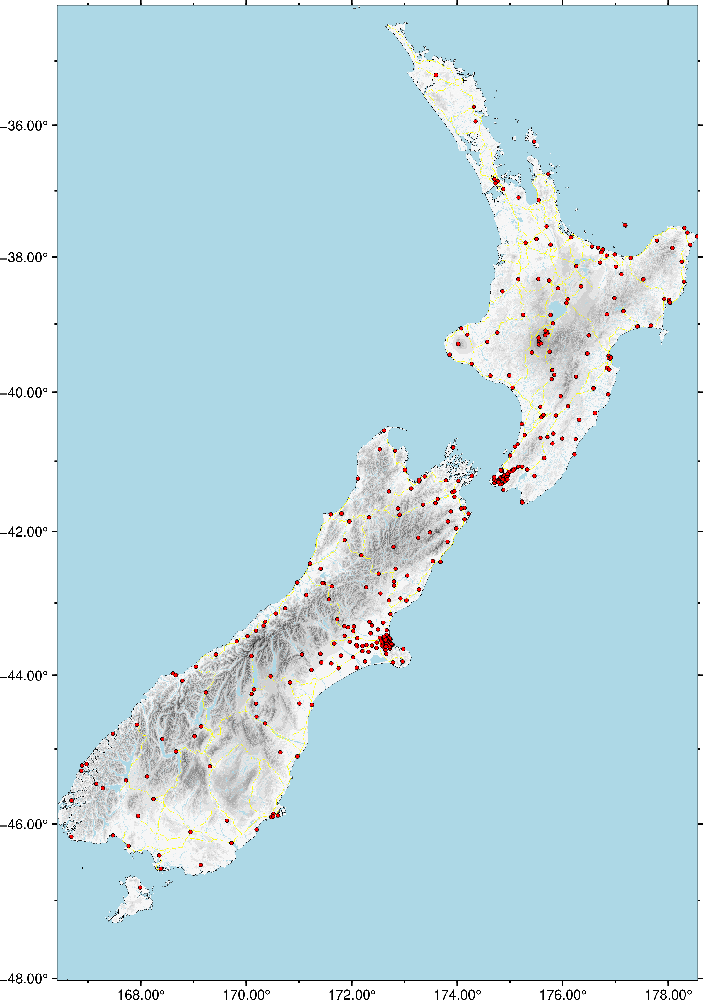

In [8]:
plot_sites(site_real_df, region="NZ", map_data=map_data)

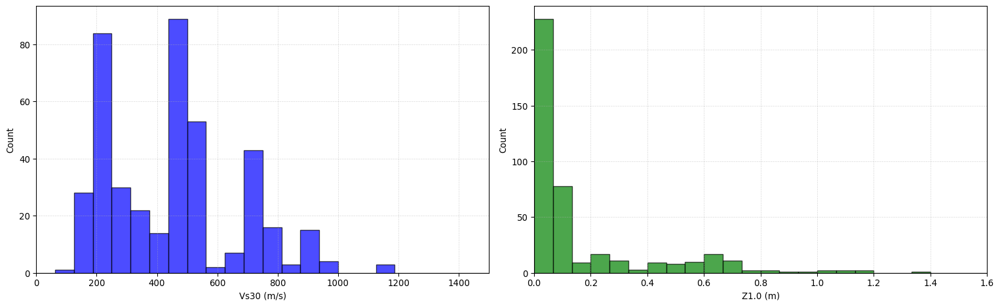

In [9]:
plot_vs30_z1p0_distribution(site_real_df)

## Level 0 Sites

In [10]:
print(f"Number of sites: {len(site_0_df)}")

Number of sites: 4191


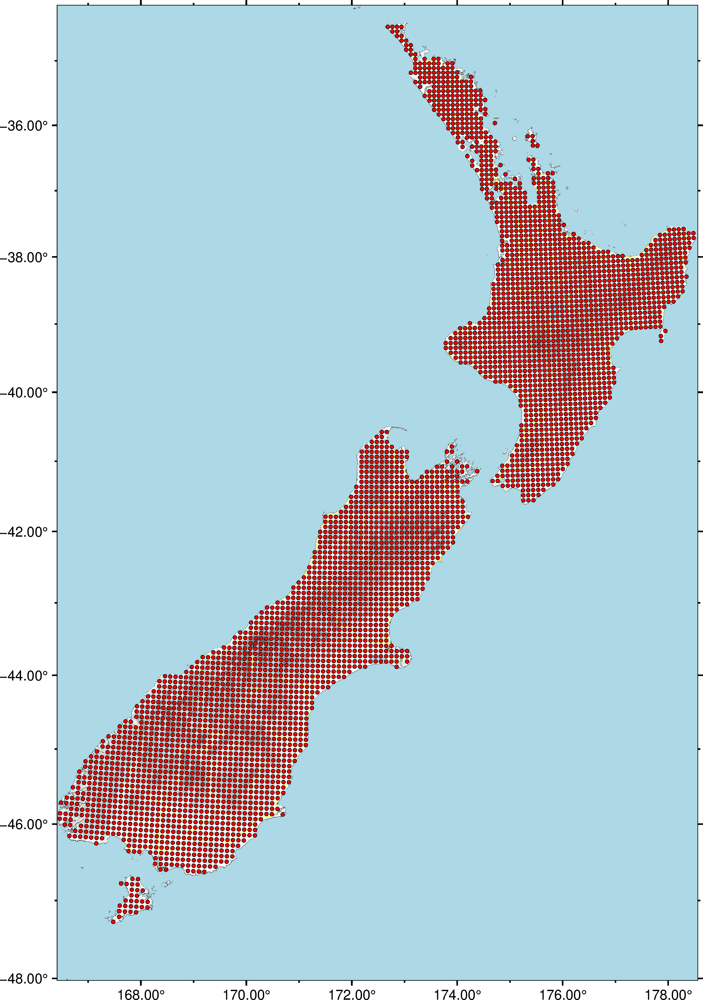

In [11]:
plot_sites(site_0_df, region="NZ", map_data=map_data)

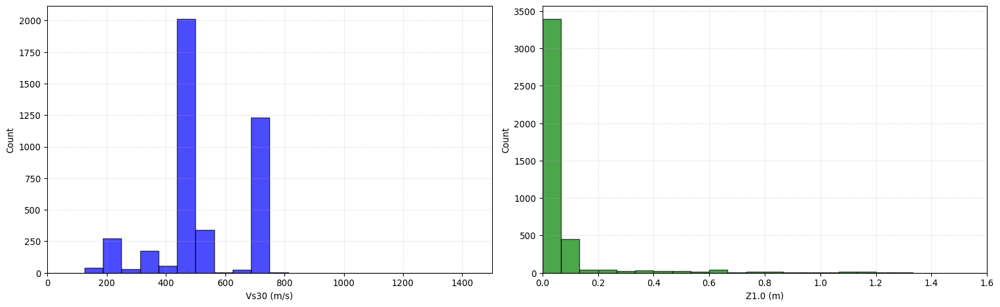

In [12]:
plot_vs30_z1p0_distribution(site_0_df)

## Level 1 Sites

In [13]:
print(f"Number of sites: {len(site_real_df)}")

Number of sites: 414


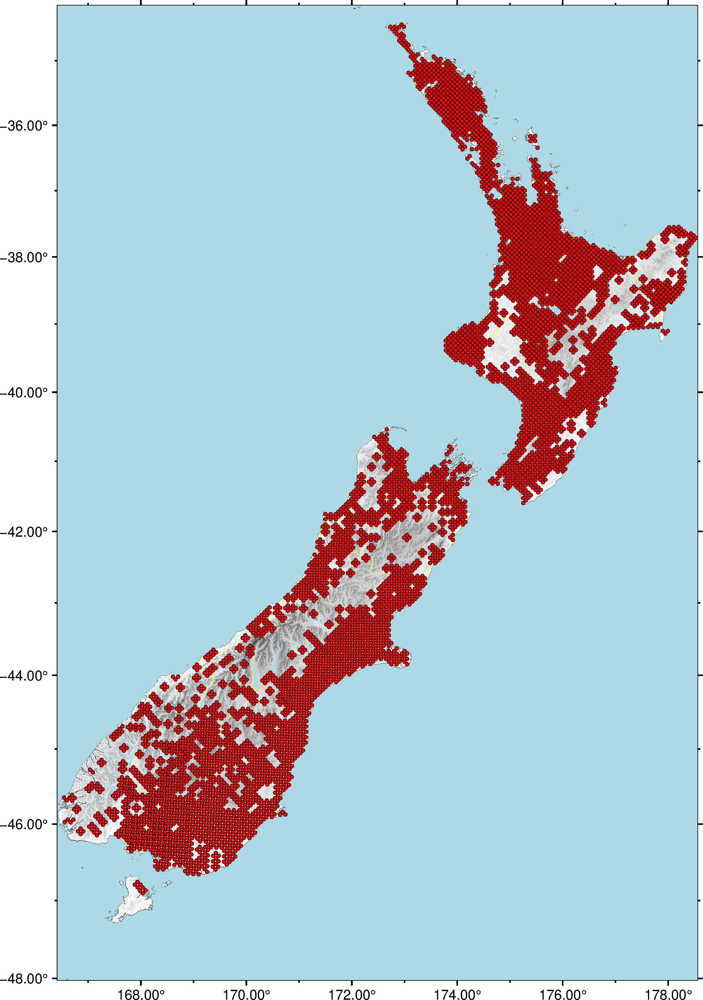

In [14]:
plot_sites(site_1_df, region="NZ", map_data=map_data)

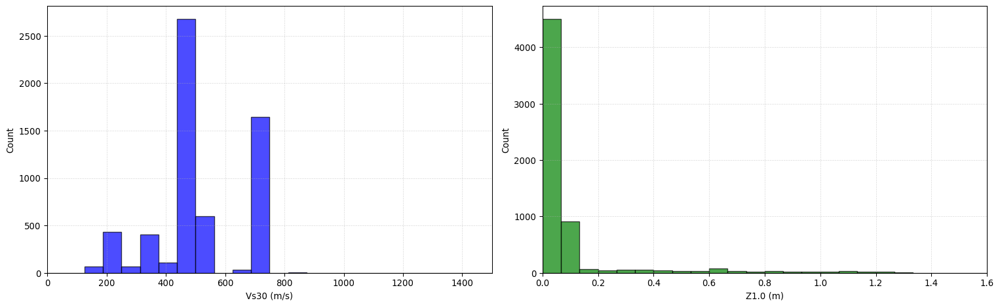

In [15]:
plot_vs30_z1p0_distribution(site_1_df)

## Level 2 Sites

In [16]:
print(f"Number of sites: {len(site_2_df)}")

Number of sites: 4608


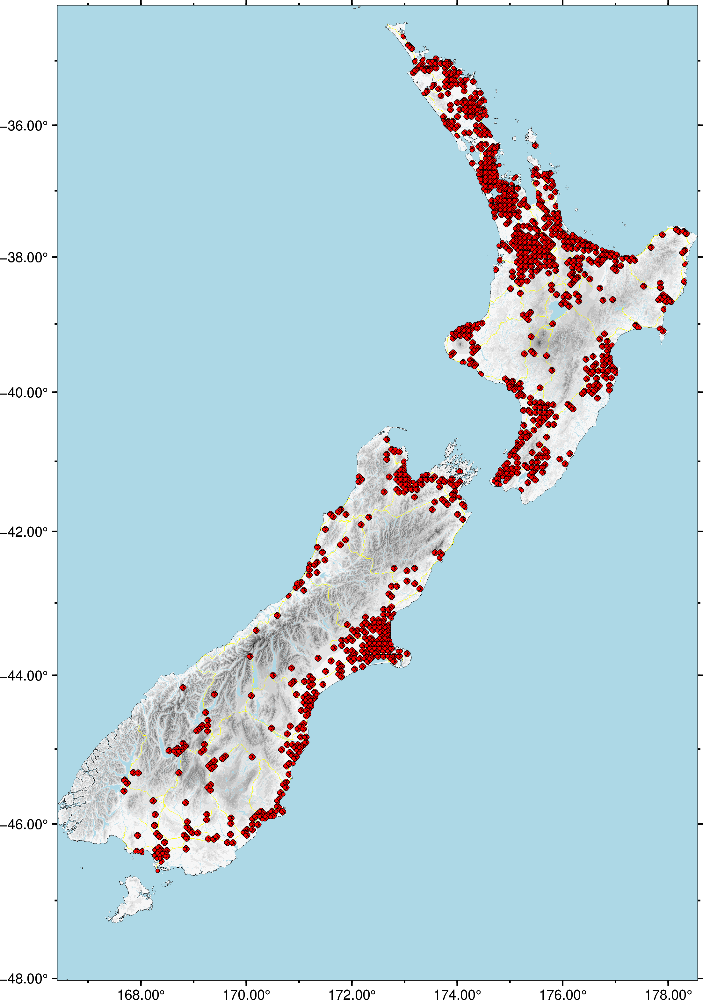

In [17]:
plot_sites(site_2_df, region="NZ", map_data=map_data)

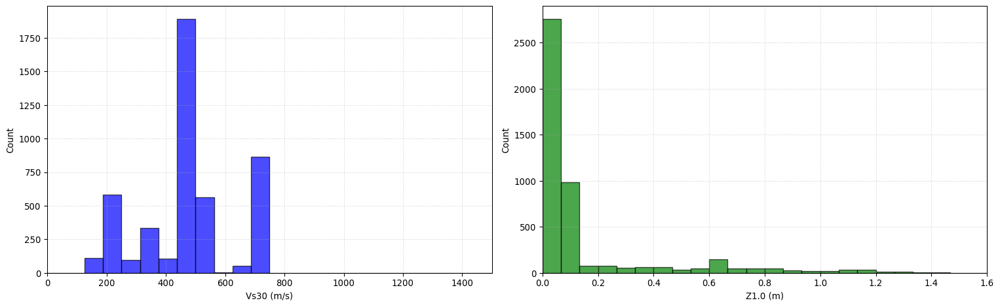

In [18]:
plot_vs30_z1p0_distribution(site_2_df)

## Level 3 Sites

In [19]:
print(f"Number of sites: {len(site_3_df)}")

Number of sites: 5223


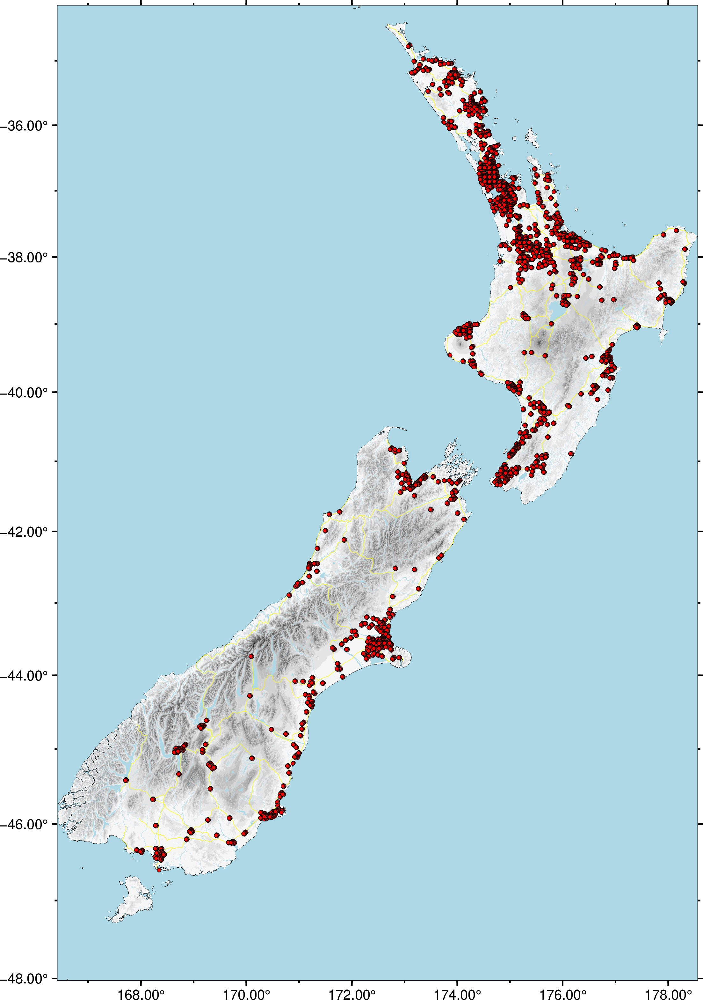

In [20]:
plot_sites(site_3_df, region="NZ", map_data=map_data)

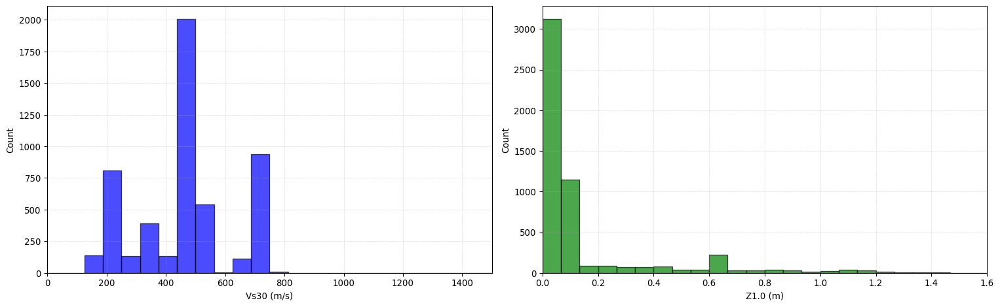

In [21]:
plot_vs30_z1p0_distribution(site_3_df)

## Level 4 Sites

In [22]:
print(f"Number of sites: {len(site_4_df)}")

Number of sites: 5480


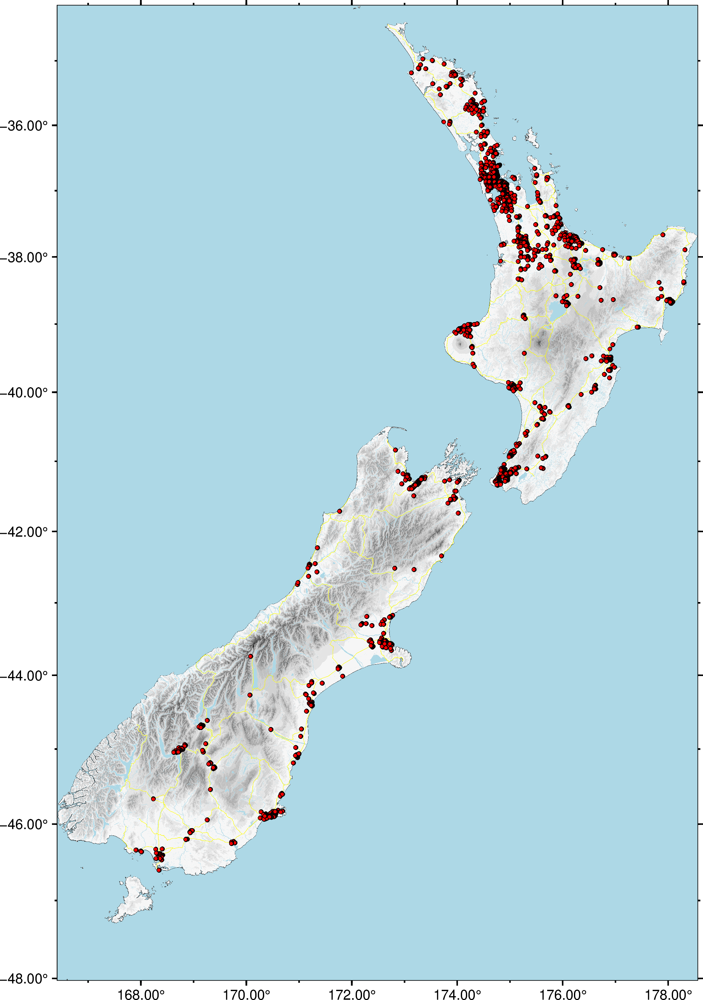

In [23]:
plot_sites(site_4_df, region="NZ", map_data=map_data)

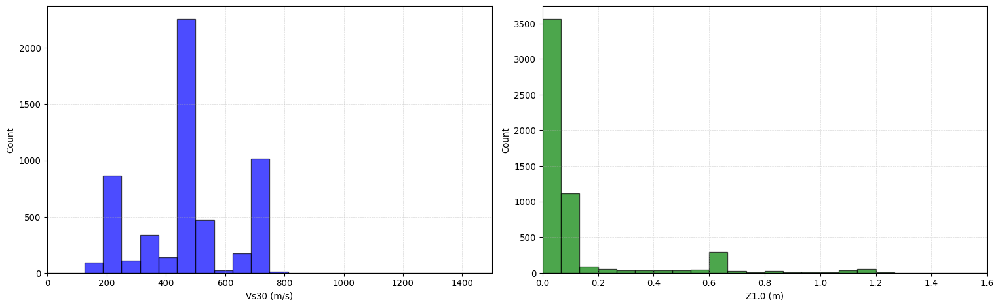

In [24]:
plot_vs30_z1p0_distribution(site_4_df)